In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

transactions_clean = pd.read_csv("clean_data/transactions_clean.csv", parse_dates=["invoice_date"])
customers_clean    = pd.read_csv("clean_data/customers_clean.csv")

print("Données chargées ✓")

Données chargées ✓


In [2]:
print("\n\n------------------------------------------------ ETAPE 1 : Construction des features RFM ----------------------------------------------")
print("\n1) À partir de transactions.csv nettoyé, calculez pour chaque client Recence / fréquence / montant")

# La snapshot date = date max du dataset (pas la date du jour)
snapshot_date = transactions_clean["invoice_date"].max()
print(f"\nSnapshot date : {snapshot_date.date()}")

print("\n====== CALCUL RFM ======")
rfm = transactions_clean.groupby("customer_id").agg(
    recence   = ("invoice_date", lambda dates: (snapshot_date - dates.max()).days),
    frequence = ("invoice_id",   "nunique"),
    montant   = ("line_total",   "sum")
).reset_index()
print(f"\nNombre de clients dans la table RFM : {len(rfm)}")
print("\nAperçu :")
print(rfm.head(20).to_string(index=False))

print("\n====== TOP 15 PAR RÉCENCE (plus récent → moins récent) ======")
print(rfm.sort_values("recence",
ascending=True).head(15).to_string(index=False))

print("\n====== TOP 15 PAR FRÉQUENCE (plus fréquent → moins fréquent) ======")
print(rfm.sort_values("frequence",
ascending=False).head(15).to_string(index=False))

print("\n====== TOP 15 PAR MONTANT (plus gros → plus petit) ======")
print(rfm.sort_values("montant",
ascending=False).head(15).to_string(index=False))

print("\n====== FEATURES SUPPLEMENTAIRES ======")
print("--> Ajout du panier moyen et de l'ancienneté (tenure)")
rfm["panier_moyen"] = rfm["montant"] / rfm["frequence"]

customers_clean["first_purchase"] = pd.to_datetime(customers_clean["first_purchase"])
anciennete = customers_clean[["customer_id", "first_purchase"]].copy()
anciennete["anciennete_jours"] = (snapshot_date - anciennete["first_purchase"]).dt.days
rfm = rfm.merge(anciennete[["customer_id", "anciennete_jours"]], on="customer_id", how="left")

print("\nStatistiques :")
print(rfm[["recence", "frequence", "montant", "panier_moyen", "anciennete_jours"]].describe().round(1))



------------------------------------------------ ETAPE 1 : Construction des features RFM ----------------------------------------------

1) À partir de transactions.csv nettoyé, calculez pour chaque client Recence / fréquence / montant

Snapshot date : 2026-06-30

====== CALCUL RFM ======



Nombre de clients dans la table RFM : 47662

Aperçu :
 customer_id  recence  frequence  montant
     12346.0      325          3   500.56
     12347.0        1          8  6472.20
     12348.0       74          5  1537.84
     12349.0       18          3  5085.38
     12350.0      309          1   459.45
     12351.0      374          1   632.28
     12352.0       35          9  3096.61
     12353.0      203          2   780.89
     12354.0      231          1  2083.84
     12355.0      213          2   900.58
     12356.0       22          6  3517.13
     12358.0        1          5  1741.74
     12360.0       51          6  6032.58
     12361.0      286          4  1179.56
     12362.0        2         10  7501.38
     12363.0      109          2   571.69
     12364.0        7          4  1916.23
     12365.0      290          1   655.12
     12366.0      633          1   132.02
     12367.0        3          1   281.50

====== TOP 15 PAR RÉCENCE (plus récent → moins récent) ======


In [3]:
print("\n\n------------------------------------------------ ETAPE 2 : Scoring RFM et segments ----------------------------------------------")
print("\nScores R, F, M de 1 à 5 par quintiles")
print("Récence inversée : un client récent (peu de jours) obtient un score R élevé.")
print("Fréquence et montant : plus c'est élevé, plus le score est élevé.")
print("Les scores F et M sont calculés sur le rang (method='first') pour gérer les ex-aequo (beaucoup de clients à 1 commande).")

rfm["R"] = pd.qcut(rfm["recence"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequence"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M"] = pd.qcut(rfm["montant"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)

print("\n====== SEUILS DES QUINTILES ======")
print("\nRécence (jours) par score R :")
print(rfm.groupby("R")["recence"].agg(["min", "max", "count"]))
print("\nFréquence (nb factures) par score F :")
print(rfm.groupby("F")["frequence"].agg(["min", "max", "mean", "count"]).round(2))
print("\nMontant (€) par score M :")
print(rfm.groupby("M")["montant"].agg(["min", "max", "mean", "count"]).round(1))

ca_total = rfm["montant"].sum()
n_clients = len(rfm)
print(f"\nBase RFM : {n_clients} clients | CA total : {ca_total:,.0f} €")

print("\n====== 1) CHAMPIONS (555 ou proche) ======")
champions_555 = rfm[rfm["RFM"] == "555"]
champions_proche = rfm[(rfm["R"] >= 4) & (rfm["F"] >= 4) & (rfm["M"] >= 4)]
print(f"Score 555 strict : {len(champions_555)} clients ({100*len(champions_555)/n_clients:.1f}% de la base)")
print(f"  -> {100*champions_555['montant'].sum()/ca_total:.1f}% du CA")
print(f"Champions 'proches' (R≥4, F≥4, M≥4) : {len(champions_proche)} clients ({100*len(champions_proche)/n_clients:.1f}% de la base)")
print(f"  -> {100*champions_proche['montant'].sum()/ca_total:.1f}% du CA")
print("--> Lecture : ~6% des clients en 555 portent déjà ~32% du CA. En élargissant au voisinage 444+,")
print("    20% des clients génèrent ~57% du CA : c'est le noyau VIP à protéger.")

print("\n====== 2) CLIENTS À RISQUE (forte valeur historique, faible récence) ======")
a_risque = rfm[(rfm["R"] <= 2) & (rfm["F"] >= 4) & (rfm["M"] >= 4)]
print(f"R≤2, F≥4, M≥4 : {len(a_risque)} clients ({100*len(a_risque)/n_clients:.1f}% de la base)")
print(f"  -> {100*a_risque['montant'].sum()/ca_total:.1f}% du CA")
print(f"  Récence : {a_risque['recence'].min():.0f} à {a_risque['recence'].max():.0f} jours | montant moyen : {a_risque['montant'].mean():.0f} €")
print("--> Lecture : ce ne sont pas des petits comptes oubliés. Ils achetaient souvent et cher,")
print("    mais leur dernier achat date d'au moins ~10 mois. Priorité winback avant qu'ils basculent en perdus.")

print("\n====== 3) SEGMENT PERDU (111) ======")
perdus_111 = rfm[rfm["RFM"] == "111"]
print(f"Score 111 : {len(perdus_111)} clients ({100*len(perdus_111)/n_clients:.1f}% de la base)")
print(f"  -> {100*perdus_111['montant'].sum()/ca_total:.1f}% du CA")
print(f"  1 seule commande, montant moyen {perdus_111['montant'].mean():.0f} €, dernier achat il y a {perdus_111['recence'].min():.0f} à {perdus_111['recence'].max():.0f} jours")
print("--> Action : les exclure des campagnes coûteuses (pub, mailing premium). Un unique email")
print("    de relance low-cost, puis arrêt si pas de réponse. Le ROI d'une réactivation agressive est trop faible.")



------------------------------------------------ ETAPE 2 : Scoring RFM et segments ----------------------------------------------

Scores R, F, M de 1 à 5 par quintiles
Récence inversée : un client récent (peu de jours) obtient un score R élevé.
Fréquence et montant : plus c'est élevé, plus le score est élevé.
Les scores F et M sont calculés sur le rang (method='first') pour gérer les ex-aequo (beaucoup de clients à 1 commande).

====== SEUILS DES QUINTILES ======

Récence (jours) par score R :
   min   max  count
R                  
1  562  1635   9507
2  310   561   9521
3  139   309   9549
4   59   138   9500
5    0    58   9585

Fréquence (nb factures) par score F :
   min  max   mean  count
F                        
1    1    1   1.00   9533
2    1    2   1.47   9532
3    2    3   2.58   9532
4    3    6   4.69   9532
5    6  155  10.90   9533

Montant (€) par score M :
     min      max    mean  count
M                               
1    6.2     70.7    38.4   9533
2   70.7   

In [4]:
print("\n====== SEGMENTATION ÉLARGIE (8 segments pour couvrir toute la base) ======")
print("Les 3 extrêmes (Champions / À risque / Perdus) laissent ~70% des clients sans étiquette.")
print("Règles par plage, appliquées dans cet ordre (premier match gagne) :")
print("""
  1. Champions              : R≥4, F≥4, M≥4
       Pourquoi ici : R≥4 = dernier achat ≤ 138 jours (encore dans un cycle d'achat normal).
       F≥4 et M≥4 = au-dessus de la médiane haute (≈ 3+ commandes et ≈ 295 €+).
  2. À risque (haute valeur): R≤2, F≥4, M≥4
       Pourquoi R≤2 : au-delà de 310 jours sans achat, le client a manqué au moins
       un cycle. On le sépare des Champions pour déclencher un winback, pas un VIP care.
  3. Perdus                 : RFM = 111
       Uniquement le quintile le plus bas sur les 3 axes : 1 commande, < 71 €, > 562 jours.
  4. Nouveaux               : R≥4 et F=1
       Une seule facture mais récente. Ce n'est pas de la fidélité, c'est de l'onboarding.
  5. Prometteurs            : R≥4, F≥2, M≥3
       Récents, déjà un 2e achat, montant correct : le vivier qui peut devenir Champion.
  6. Fidèles                : R≥3, F≥3, M≥3
       Cœur de base encore actif (≤ 309 jours) mais moins chaud que les Champions.
  7. Endormis               : R≤2 et M≥3
       Valeur passée réelle, mais plus silencieux que les 'À risque' (fréquence moindre).
  8. Occasionnels           : le reste
       Petits volumes, mix récence. À traiter en automatique, pas en one-to-one.
""")

def attribuer_segment(row):
    R, F, M = row["R"], row["F"], row["M"]
    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"
    if R <= 2 and F >= 4 and M >= 4:
        return "À risque (haute valeur)"
    if R == 1 and F == 1 and M == 1:
        return "Perdus"
    if R >= 4 and F == 1:
        return "Nouveaux"
    if R >= 4 and F >= 2 and M >= 3:
        return "Prometteurs"
    if R >= 3 and F >= 3 and M >= 3:
        return "Fidèles"
    if R <= 2 and M >= 3:
        return "Endormis"
    return "Occasionnels"

rfm["segment"] = rfm.apply(attribuer_segment, axis=1)

ordre_segments = [
    "Champions", "Prometteurs", "Fidèles", "Nouveaux",
    "À risque (haute valeur)", "Endormis", "Occasionnels", "Perdus"
]
rfm["segment"] = pd.Categorical(rfm["segment"], categories=ordre_segments, ordered=True)

carte_segments = (
    rfm.groupby("segment", observed=True)
    .agg(
        nb_clients=("customer_id", "count"),
        ca=("montant", "sum"),
        recence_mediane=("recence", "median"),
        frequence_moy=("frequence", "mean"),
        montant_moy=("montant", "mean"),
        panier_moy=("panier_moyen", "mean"),
        anciennete_mediane=("anciennete_jours", "median"),
    )
)
carte_segments["part_clients_pct"] = 100 * carte_segments["nb_clients"] / n_clients
carte_segments["part_ca_pct"] = 100 * carte_segments["ca"] / ca_total
carte_segments = carte_segments.round({"frequence_moy": 1, "montant_moy": 0, "panier_moy": 1,
                                       "part_clients_pct": 1, "part_ca_pct": 1, "ca": 0})

print("====== CARTE DES 8 SEGMENTS ======")
print(carte_segments.to_string())
print(f"\nContrôle : {int(carte_segments['nb_clients'].sum())} clients couverts / {n_clients}")


====== SEGMENTATION ÉLARGIE (8 segments pour couvrir toute la base) ======
Les 3 extrêmes (Champions / À risque / Perdus) laissent ~70% des clients sans étiquette.
Règles par plage, appliquées dans cet ordre (premier match gagne) :

  1. Champions              : R≥4, F≥4, M≥4
       Pourquoi ici : R≥4 = dernier achat ≤ 138 jours (encore dans un cycle d'achat normal).
       F≥4 et M≥4 = au-dessus de la médiane haute (≈ 3+ commandes et ≈ 295 €+).
  2. À risque (haute valeur): R≤2, F≥4, M≥4
       Pourquoi R≤2 : au-delà de 310 jours sans achat, le client a manqué au moins
       un cycle. On le sépare des Champions pour déclencher un winback, pas un VIP care.
  3. Perdus                 : RFM = 111
       Uniquement le quintile le plus bas sur les 3 axes : 1 commande, < 71 €, > 562 jours.
  4. Nouveaux               : R≥4 et F=1
       Une seule facture mais récente. Ce n'est pas de la fidélité, c'est de l'onboarding.
  5. Prometteurs            : R≥4, F≥2, M≥3
       Récents, déjà un 2


====== VISUALISATION : distribution des scores et matrice RFM ======


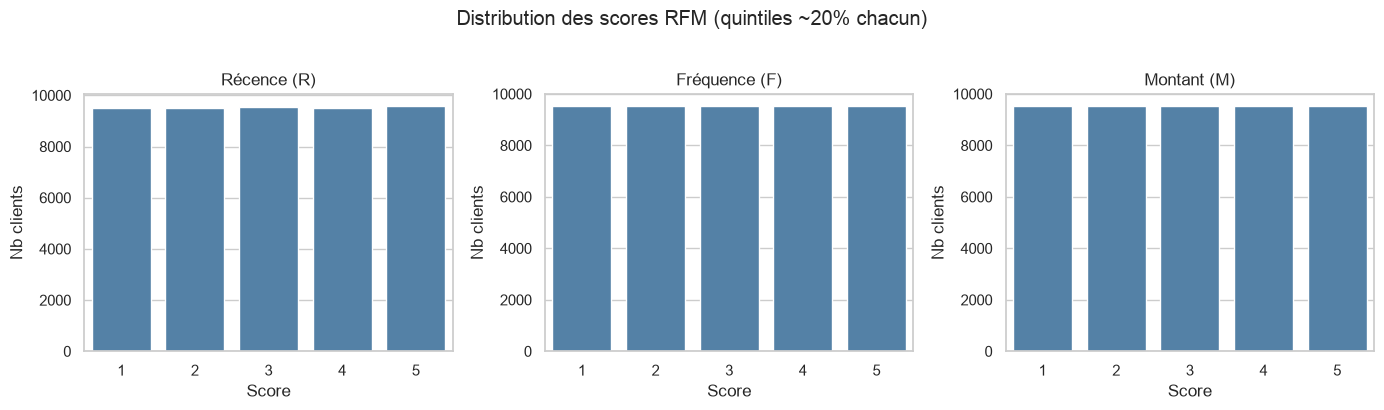

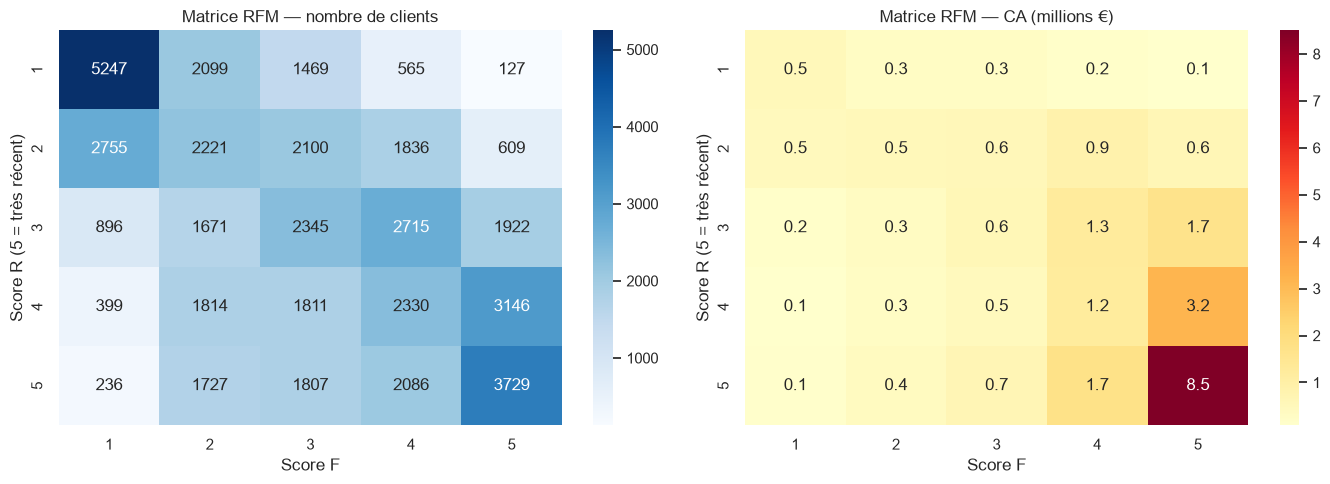

--> La masse des clients est en bas à gauche de la matrice (R et F faibles).
--> Le CA, lui, se concentre en haut à droite (R=5, F=5) : peu de clients, beaucoup de valeur.


In [5]:
print("\n====== VISUALISATION : distribution des scores et matrice RFM ======")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, titre in zip(axes, ["R", "F", "M"], ["Récence (R)", "Fréquence (F)", "Montant (M)"]):
    sns.countplot(data=rfm, x=col, ax=ax, color="steelblue")
    ax.set_title(titre)
    ax.set_xlabel("Score")
    ax.set_ylabel("Nb clients")
plt.suptitle("Distribution des scores RFM (quintiles ~20% chacun)", y=1.02)
plt.tight_layout()
plt.show()

matrice_count = pd.crosstab(rfm["R"], rfm["F"])
matrice_ca = pd.crosstab(rfm["R"], rfm["F"], values=rfm["montant"], aggfunc="sum") / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(matrice_count, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Matrice RFM — nombre de clients")
axes[0].set_xlabel("Score F")
axes[0].set_ylabel("Score R (5 = très récent)")

sns.heatmap(matrice_ca, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Matrice RFM — CA (millions €)")
axes[1].set_xlabel("Score F")
axes[1].set_ylabel("Score R (5 = très récent)")
plt.tight_layout()
plt.show()

print("--> La masse des clients est en bas à gauche de la matrice (R et F faibles).")
print("--> Le CA, lui, se concentre en haut à droite (R=5, F=5) : peu de clients, beaucoup de valeur.")



------------------------------------------------ ETAPE 3 : Visualisation et profilage ----------------------------------------------

====== PROFIL DÉMOGRAPHIQUE PAR SEGMENT ======

1) Pays (part France) et ancienneté
                            nb  part_france_pct  anciennete_mediane  recence_mediane
segment                                                                             
Champions                 9691             91.3               629.0             56.0
Prometteurs               4241             89.6               284.0             60.0
Fidèles                   5814             90.7               691.0            204.0
Nouveaux                   635             89.3                77.0             73.0
À risque (haute valeur)   2021             93.9               947.0            430.0
Endormis                  5692             92.6               849.5            511.0
Occasionnels             16582             90.8               565.0            312.0
Perdus         

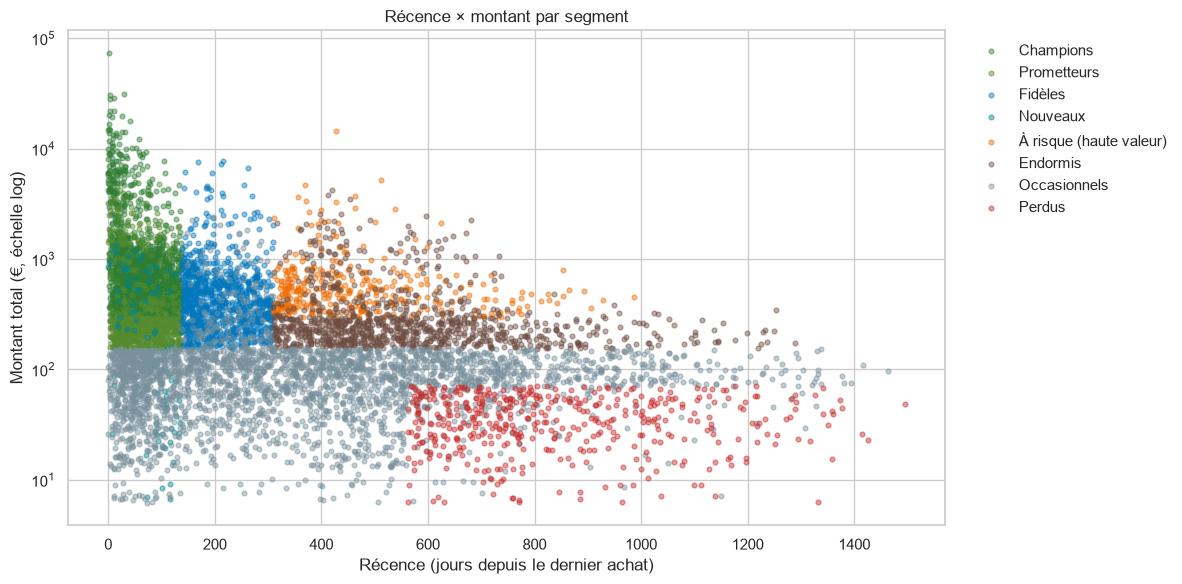

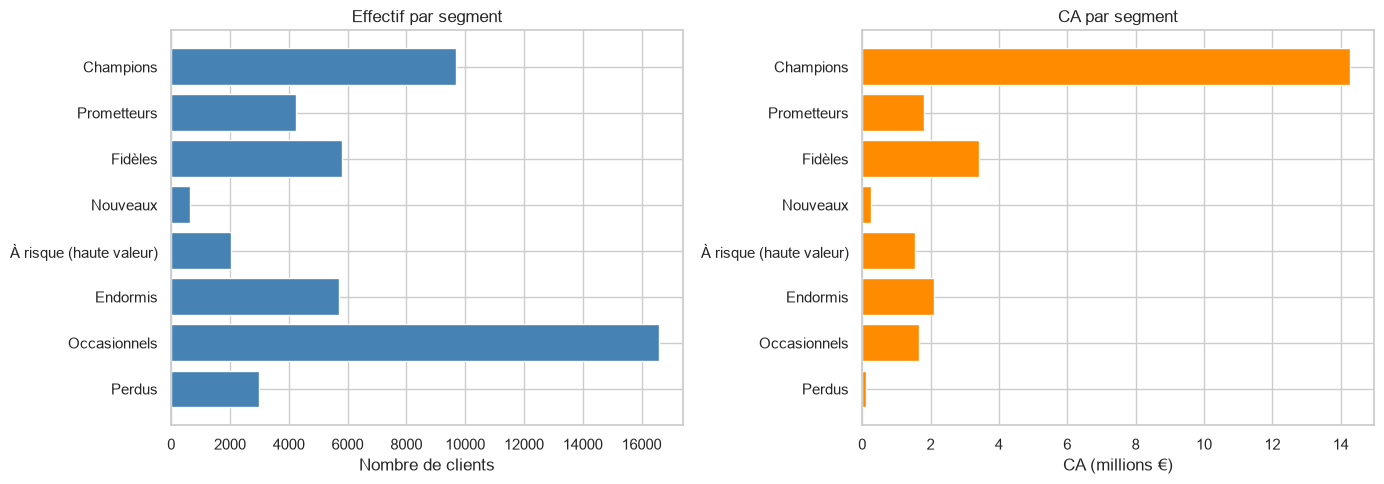

--> Les Occasionnels sont le plus gros effectif mais pèsent peu en CA.
--> Les Champions inversent le rapport : 20% des clients, ~57% du CA.


In [6]:
print("\n\n------------------------------------------------ ETAPE 3 : Visualisation et profilage ----------------------------------------------")

rfm_profil = rfm.merge(
    customers_clean[["customer_id", "country", "declared_preference", "age_bracket", "life_stage", "urban_density"]],
    on="customer_id",
    how="left",
)

print("\n====== PROFIL DÉMOGRAPHIQUE PAR SEGMENT ======")
print("\n1) Pays (part France) et ancienneté")
profil_geo = (
    rfm_profil.groupby("segment", observed=True)
    .agg(
        nb=("customer_id", "count"),
        part_france_pct=("country", lambda s: 100 * (s == "France").mean()),
        anciennete_mediane=("anciennete_jours", "median"),
        recence_mediane=("recence", "median"),
    )
    .round(1)
)
print(profil_geo.to_string())
print("\n--> Limite : la France pèse ~90% dans tous les segments (biais déjà vu au TP1).")
print("    Le pays ne discrimine presque pas. L'ancienneté, si : les Nouveaux ont ~77 jours")
print("    de tenure, les Perdus et À risque plus de 900 jours. Ce sont des cohortes différentes.")

print("\n2) Top 3 pays par segment")
for seg in ordre_segments:
    top = rfm_profil.loc[rfm_profil["segment"] == seg, "country"].value_counts(normalize=True).head(3).mul(100).round(1)
    print(f"  {seg:28} {top.to_dict()}")

palette = {
    "Champions": "#2e7d32",
    "Prometteurs": "#558b2f",
    "Fidèles": "#0277bd",
    "Nouveaux": "#00838f",
    "À risque (haute valeur)": "#ef6c00",
    "Endormis": "#6d4c41",
    "Occasionnels": "#78909c",
    "Perdus": "#c62828",
}

print("\n====== SCATTER RÉCENCE × MONTANT (coloré par segment) ======")
print("Échantillon de 8 000 clients pour la lisibilité. Axe Y en log : la relation n'est pas linéaire.")
print("Des clients très récents (gauche) ET très anciens (droite) peuvent avoir un fort montant.")

echantillon = rfm.sample(n=min(8000, len(rfm)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
for seg in ordre_segments:
    sous = echantillon[echantillon["segment"] == seg]
    ax.scatter(sous["recence"], sous["montant"], s=12, alpha=0.45, label=seg, color=palette[seg])
ax.set_yscale("log")
ax.set_xlabel("Récence (jours depuis le dernier achat)")
ax.set_ylabel("Montant total (€, échelle log)")
ax.set_title("Récence × montant par segment")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ca_seg = carte_segments["ca"] / 1e6
axes[0].barh(carte_segments.index.astype(str), carte_segments["nb_clients"], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_xlabel("Nombre de clients")
axes[0].set_title("Effectif par segment")
axes[1].barh(carte_segments.index.astype(str), ca_seg, color="darkorange")
axes[1].invert_yaxis()
axes[1].set_xlabel("CA (millions €)")
axes[1].set_title("CA par segment")
plt.tight_layout()
plt.show()

print("--> Les Occasionnels sont le plus gros effectif mais pèsent peu en CA.")
print("--> Les Champions inversent le rapport : 20% des clients, ~57% du CA.")

In [7]:
print("\n\n------------------------------------------------ ETAPE 4 : Recommandations marketing par segment ----------------------------------------------")
print("\nPour chaque segment : profil, potentiel, risque, action, métrique de succès.\n")

fiches = {
    "Champions": """
- Qui : clients récents, fréquents, gros dépensiers (médiane ~56 j, ~10 commandes, ~1 470 €).
- Potentiel : déjà 57% du CA. Potentiel = upsell rituel / abonnement, pas l'acquisition.
- Risque : faible churn immédiat, mais un faux pas (stock, SAV) coûte cher. À ne PAS spammer.
- Action : programme VIP, avant-premières, cadeau de fidélité. Canal : email premium + SMS rare.
- Succès : % de Champions avec ≥1 commande dans les 60 jours ; panier moyen stable ou en hausse.
""",
    "À risque (haute valeur)": """
- Qui : même valeur historique que des fidèles/champions, mais silencieux depuis ≥ 310 jours.
- Potentiel : récupérer ~6% du CA déjà 'en stock'. Moins cher à réactiver qu'à recruter.
- Risque : bascule vers Perdus si on attend encore un trimestre.
- Action : winback personnalisé (best-sellers déjà achetés), offre de relance unique, délai court.
- Succès : taux de réactivation à 30 jours. Si < 5%, passer en Endormis / stop spend.
""",
    "Prometteurs": """
- Qui : récents, 2-3 commandes, ticket déjà correct (~427 €). Vivier Champions.
- Potentiel : croissance. Un 4e achat les rapproche du cœur VIP.
- Risque : s'arrêter après l'essai si l'expérience 2e commande déçoit.
- Action : scénario '2e puis 3e commande' (routine + coffret découverte). Pas de remise trop forte.
- Succès : % qui passent à F≥4 dans les 90 jours.
""",
    "Fidèles": """
- Qui : cœur actif mais moins chaud (récence médiane ~200 j, ~6 commandes).
- Potentiel : maintenir, éviter le glissement vers À risque.
- Risque : moyen — un cycle manqué et ils basculent.
- Action : newsletter rituel, rappel de réassort, cross-sell catégorie complémentaire.
- Succès : récence médiane qui ne se dégrade pas trimestre après trimestre.
""",
    "Nouveaux": """
- Qui : 1 seule facture, récente (≤ 138 j). Ancienneté médiane ~77 j. Panier souvent plus élevé
  que les Occasionnels (certains sont de 'vrais' premiers paniers, pas des petits coups).
- Potentiel : conversion en Prometteurs. Fenêtre courte après le 1er achat.
- Risque : one-shot si pas d'onboarding.
- Action : série J+3 / J+15 / J+40 (usage produit, rituel, 2e commande). Canal email, pas pub chère.
- Succès : taux de 2e commande à 45 jours.
""",
    "Endormis": """
- Qui : M≥3 mais R≤2, fréquence plus basse que les À risque. Anciens gros/moyens paniers endormis.
- Potentiel : winback sélectif (meilleur que les Perdus, moins urgent que les À risque).
- Risque : oubli de marque. Beaucoup n'ont jamais été vraiment fréquents.
- Action : 1 campagne 'on vous a manqué' + best-seller de saison. Pas de séquence longue.
- Succès : taux de réactivation à 30 jours, coût par client réactivé vs CAC.
""",
    "Occasionnels": """
- Qui : 35% de la base, ~7% du CA. Petits tickets, 1-2 commandes, mix de récence.
- Potentiel : faible unitairement ; volume seulement si le coût de contact est quasi nul.
- Risque : diluer le budget. Traités comme les Champions, ils ruinent le ROI.
- Action : flux automatisés (newsletter, retargeting light). Exclusion des campagnes coûteuses.
- Succès : CA / contact, pas le taux d'ouverture. Objectif = ne pas dépenser plus qu'ils rapportent.
""",
    "Perdus": """
- Qui : RFM 111 — 1 commande, ~36 €, plus de 18 mois. 6% des clients, 0,4% du CA.
- Potentiel : négligeable.
- Risque : aucun (déjà partis). Le vrai risque est de leur parler trop cher.
- Action : exclusion. Au plus un email générique de réactivation, puis suppression de la pression.
- Succès : ne plus les retrouver dans les listes payantes au trimestre suivant.
""",
}

for seg in ordre_segments:
    print(f"===== {seg} =====")
    print(fiches[seg])

print("====== PRIORISATION (1 = à traiter en premier) ======")
print("""
Rang  Segment                    Critère qui justifie le rang              Budget / temps réel
1     À risque (haute valeur)    Risque de perte d'une valeur déjà connue  Équipe + offre (le plus d'heures / client)
2     Champions                  Valeur actuelle (57% du CA)               Care VIP, faible volume, haute qualité
3     Prometteurs                Potentiel de croissance vers Champions    Scénarios CRM, effort moyen
4     Nouveaux                   Fenêtre d'onboarding courte               Automation soignée, pas de media lourd
5     Fidèles                    Prévention du glissement                  Newsletter / réassort, semi-auto
6     Endormis                   Winback secondaire                        1 campagne, puis stop
7     Occasionnels               Volume faible valeur                      100% automatique, budget plancher
8     Perdus                     Valeur nulle, exclusion                   Zéro budget (liste d'exclusion)

Vérification pratique : les rangs 1 et 2 n'ont PAS le même traitement
(winback urgent vs care VIP). Les rangs 7 et 8 n'ont pas de commercial dédié.
Si 1 et 4 recevaient le même email générique, la priorisation serait théorique :
ici le rang 1 a une offre et un suivi, le rang 4 un drip onboarding.
""")



------------------------------------------------ ETAPE 4 : Recommandations marketing par segment ----------------------------------------------

Pour chaque segment : profil, potentiel, risque, action, métrique de succès.

===== Champions =====

- Qui : clients récents, fréquents, gros dépensiers (médiane ~56 j, ~10 commandes, ~1 470 €).
- Potentiel : déjà 57% du CA. Potentiel = upsell rituel / abonnement, pas l'acquisition.
- Risque : faible churn immédiat, mais un faux pas (stock, SAV) coûte cher. À ne PAS spammer.
- Action : programme VIP, avant-premières, cadeau de fidélité. Canal : email premium + SMS rare.
- Succès : % de Champions avec ≥1 commande dans les 60 jours ; panier moyen stable ou en hausse.

===== Prometteurs =====

- Qui : récents, 2-3 commandes, ticket déjà correct (~427 €). Vivier Champions.
- Potentiel : croissance. Un 4e achat les rapproche du cœur VIP.
- Risque : s'arrêter après l'essai si l'expérience 2e commande déçoit.
- Action : scénario '2e puis 3e command

In [8]:
print("\n====== POUR ALLER PLUS LOIN ======")
print("\n1) Adapter les quintiles à une base de 50 clients (auto-entrepreneur)")
print("Les quintiles n'ont pas de sens : 20% = 10 personnes, et 1 client 'Champion' fausse tout.")
print("Paliers manuels possibles, lus dans les données (pas dans une table de loi) :")
print("  R : ≤ 60 j / 61-180 j / > 180 j   (encore dans le cycle / à relancer / perdu)")
print("  F : 1 commande / 2-3 / 4+         (essai / répétition / habitude)")
print("  M : sous la médiane / médiane-2x / > 2x médiane")
print("On nomme 4-5 groupes à la main, on relit chaque fiche client, on n'automatise pas.")

print("\n2) Croisement zero-party : segment Nouveaux × urban_density / age_bracket")
print("Les Champions ont un profil déclaré quasi identique à la base (préférences peau ~14% chacune).")
print("Le RFM ne dit pas POURQUOI ils achètent. On croise donc un segment actionnable — les Nouveaux —")
print("avec les champs du quiz de bienvenue (sparse : ~20-40% de remplissage).")

nouveaux = rfm_profil[rfm_profil["segment"] == "Nouveaux"]
print(f"\nNouveaux avec urban_density renseigné : {nouveaux['urban_density'].notna().mean()*100:.1f}%")
print(f"Nouveaux avec age_bracket renseigné   : {nouveaux['age_bracket'].notna().mean()*100:.1f}%")

def dist_pct(series):
    return series.dropna().value_counts(normalize=True).mul(100).round(1)

comparaison_urbain = pd.DataFrame({
    "base": dist_pct(rfm_profil["urban_density"]),
    "Nouveaux": dist_pct(nouveaux["urban_density"]),
})
comparaison_age = pd.DataFrame({
    "base": dist_pct(rfm_profil["age_bracket"]),
    "Nouveaux": dist_pct(nouveaux["age_bracket"]),
})
print("\n--- urban_density (%) ---")
print(comparaison_urbain)
print("\n--- age_bracket (%) ---")
print(comparaison_age)

print("\n--> Oui, le croisement affine le RFM :")
print("    les Nouveaux sont plus souvent en zone rurale (~40% vs ~33% sur la base)")
print("    et un peu plus 25-34 ans (~24% vs ~20%).")
print("--> Action RFM générique = 'email 2e commande à J+15'.")
print("--> Action insight-driven = même objectif, mais message rituel / livraison et")
print("    preuve d'usage (moins de 'pop-up boutique Paris'), canal email plutôt que retail local.")
print("    Limite : ~20% seulement ont renseigné urban_density — on ne personnalise que ce sous-ensemble.")


====== POUR ALLER PLUS LOIN ======

1) Adapter les quintiles à une base de 50 clients (auto-entrepreneur)
Les quintiles n'ont pas de sens : 20% = 10 personnes, et 1 client 'Champion' fausse tout.
Paliers manuels possibles, lus dans les données (pas dans une table de loi) :
  R : ≤ 60 j / 61-180 j / > 180 j   (encore dans le cycle / à relancer / perdu)
  F : 1 commande / 2-3 / 4+         (essai / répétition / habitude)
  M : sous la médiane / médiane-2x / > 2x médiane
On nomme 4-5 groupes à la main, on relit chaque fiche client, on n'automatise pas.

2) Croisement zero-party : segment Nouveaux × urban_density / age_bracket
Les Champions ont un profil déclaré quasi identique à la base (préférences peau ~14% chacune).
Le RFM ne dit pas POURQUOI ils achètent. On croise donc un segment actionnable — les Nouveaux —
avec les champs du quiz de bienvenue (sparse : ~20-40% de remplissage).

Nouveaux avec urban_density renseigné : 16.2%
Nouveaux avec age_bracket renseigné   : 42.0%

--- urban_de



------------------------------------------------ COMPLÉMENT : types de produits les plus vendus par saison ----------------------------------------------
Saisons météorologiques : Hiver=déc-fév, Printemps=mar-mai, Été=juin-août, Automne=sep-nov
On mesure la quantité (unités) ET le CA, car un coffret se vend moins mais pèse plus en €.

====== QUANTITÉS (unités) PAR SAISON × CATÉGORIE ======
category   Accessoire   Bain  Cheveux  Coffret  Corps  Visage
saison                                                       
Hiver           41060  35798    43938    24119  67922   80530
Printemps       52862  47545    57631    30408  94162  107935
Été             41311  36203    44937    23367  73498   85833
Automne         36607  33666    41656    22770  63550   73471

Part de volume (%)
category   Accessoire  Bain  Cheveux  Coffret  Corps  Visage
saison                                                      
Hiver            14.0  12.2     15.0      8.2   23.2    27.5
Printemps        13.5  12.2   

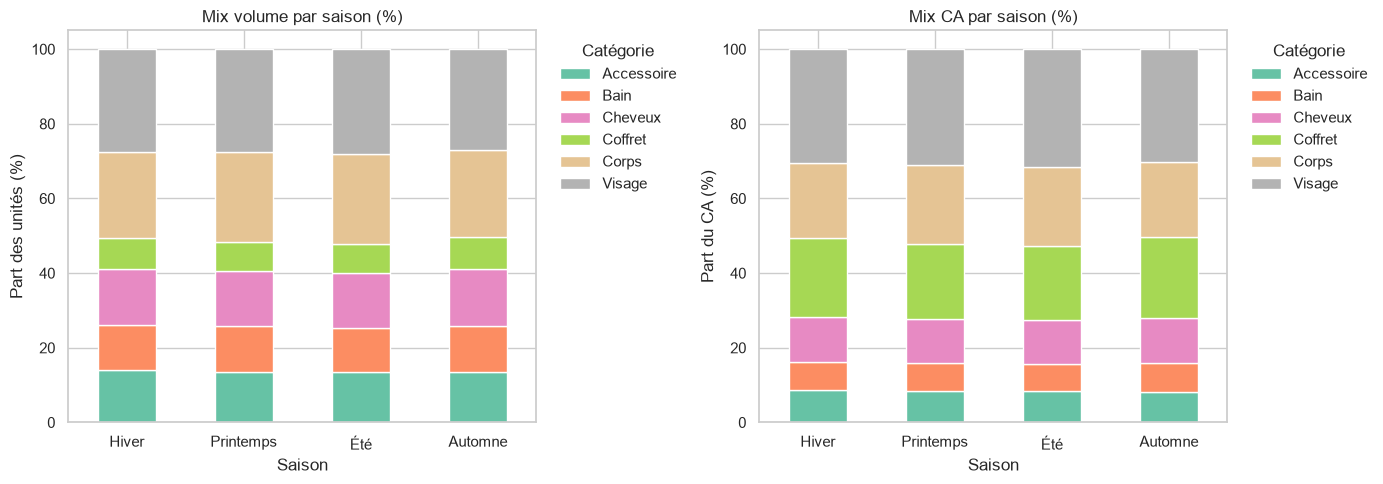


====== TOP 5 PRODUITS (unités) PAR SAISON ======
   saison  rang                               produit  categorie  unites
    Hiver     1           Trousse Voyage Rechargeable Accessoire   14788
    Hiver     2            Contour des Yeux Concombre     Visage   14705
    Hiver     3            Huile Capillaire Ricin Bio    Cheveux   14576
    Hiver     4     Huile de Bain Relaxante Camomille       Bain   14506
    Hiver     5        Brosse Corps Fibres Naturelles Accessoire   13635
Printemps     1           Trousse Voyage Rechargeable Accessoire   19543
Printemps     2                 Savon Surgras Lavande      Corps   18907
Printemps     3            Contour des Yeux Concombre     Visage   18868
Printemps     4     Huile de Bain Relaxante Camomille       Bain   18449
Printemps     5            Huile Capillaire Ricin Bio    Cheveux   18391
      Été     1           Trousse Voyage Rechargeable Accessoire   16127
      Été     2            Contour des Yeux Concombre     Visage   15630
 

In [9]:
print("\n\n------------------------------------------------ COMPLÉMENT : types de produits les plus vendus par saison ----------------------------------------------")
print("Saisons météorologiques : Hiver=déc-fév, Printemps=mar-mai, Été=juin-août, Automne=sep-nov")
print("On mesure la quantité (unités) ET le CA, car un coffret se vend moins mais pèse plus en €.")

tx_saison = transactions_clean.copy()
tx_saison["mois"] = tx_saison["invoice_date"].dt.month
tx_saison["saison"] = tx_saison["mois"].map({
    12: "Hiver", 1: "Hiver", 2: "Hiver",
    3: "Printemps", 4: "Printemps", 5: "Printemps",
    6: "Été", 7: "Été", 8: "Été",
    9: "Automne", 10: "Automne", 11: "Automne",
})
ordre_saisons = ["Hiver", "Printemps", "Été", "Automne"]
tx_saison["saison"] = pd.Categorical(tx_saison["saison"], categories=ordre_saisons, ordered=True)

qty_saison = tx_saison.groupby(["saison", "category"], observed=True)["quantity"].sum().unstack(fill_value=0)
ca_saison = tx_saison.groupby(["saison", "category"], observed=True)["line_total"].sum().unstack(fill_value=0)

qty_part = qty_saison.div(qty_saison.sum(axis=1), axis=0) * 100
ca_part = ca_saison.div(ca_saison.sum(axis=1), axis=0) * 100

print("\n====== QUANTITÉS (unités) PAR SAISON × CATÉGORIE ======")
print(qty_saison.astype(int).to_string())
print("\nPart de volume (%)")
print(qty_part.round(1).to_string())

print("\n====== CA (€) PAR SAISON × CATÉGORIE ======")
print(ca_saison.round(0).to_string())
print("\nPart de CA (%)")
print(ca_part.round(1).to_string())

print("\n====== GAGNANT PAR SAISON ======")
resume_saison = pd.DataFrame({
    "top_volume": qty_saison.idxmax(axis=1),
    "part_volume_pct": qty_part.max(axis=1).round(1),
    "n2_volume": qty_saison.apply(lambda r: r.nlargest(2).index[1], axis=1),
    "top_ca": ca_saison.idxmax(axis=1),
    "part_ca_pct": ca_part.max(axis=1).round(1),
    "n2_ca": ca_saison.apply(lambda r: r.nlargest(2).index[1], axis=1),
    "ca_total": ca_saison.sum(axis=1).round(0),
})
print(resume_saison.to_string())

print("\n--> Visage est n°1 en volume ET en CA aux 4 saisons (~27-28% des unités, ~30-32% du CA).")
print("--> N°2 volume = Corps toute l'année. N°2 CA = Coffret en hiver/automne, Corps au printemps/été.")
print("--> Le printemps est la saison la plus forte en volume et en CA (pics avril-juin).")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
qty_part.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Mix volume par saison (%)")
axes[0].set_xlabel("Saison")
axes[0].set_ylabel("Part des unités (%)")
axes[0].legend(title="Catégorie", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
axes[0].tick_params(axis="x", rotation=0)

ca_part.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("Mix CA par saison (%)")
axes[1].set_xlabel("Saison")
axes[1].set_ylabel("Part du CA (%)")
axes[1].legend(title="Catégorie", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("\n====== TOP 5 PRODUITS (unités) PAR SAISON ======")
tops = []
for saison in ordre_saisons:
    top = (
        tx_saison[tx_saison["saison"] == saison]
        .groupby(["product_name", "category"], as_index=False)["quantity"]
        .sum()
        .sort_values("quantity", ascending=False)
        .head(5)
        .assign(saison=saison)
    )
    top.insert(0, "rang", range(1, 6))
    tops.append(top)

top_saisons = pd.concat(tops, ignore_index=True)[
    ["saison", "rang", "product_name", "category", "quantity"]
]
top_saisons.columns = ["saison", "rang", "produit", "categorie", "unites"]
print(top_saisons.to_string(index=False))



------------------------------------------------ PRODUIT LE PLUS VENDU : SEGMENT × SAISON ----------------------------------------------
Métrique : quantité (unités). Un coffret pèse plus en € mais se vend moins souvent.
Nouveaux = 1 commande récente (≤ 138 j) → pas d'historique en automne, d'où la case vide.

====== DÉTAIL ======
                segment    saison                          product_name   category  unites
              Champions     Hiver            Contour des Yeux Concombre     Visage    8325
              Champions Printemps                 Savon Surgras Lavande      Corps   11564
              Champions       Été           Trousse Voyage Rechargeable Accessoire    9257
              Champions   Automne            Huile Capillaire Ricin Bio    Cheveux    7866
            Prometteurs     Hiver     Huile de Bain Relaxante Camomille       Bain     834
            Prometteurs Printemps           Trousse Voyage Rechargeable Accessoire    2194
            Prometteurs     

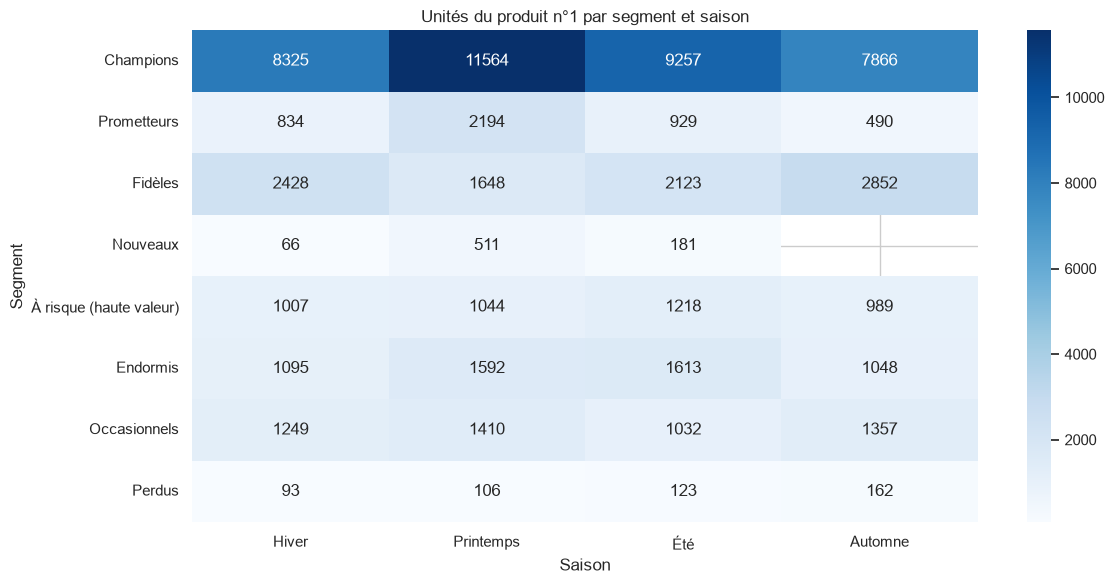


--> Lecture :
    Champions : le n°1 tourne avec la saison (contour yeux / savon / trousse / huile ricin).
    Fidèles et À risque : Contour des Yeux Concombre presque toute l'année, huile ricin ou trousse en automne.
    Occasionnels / Perdus : petits volumes, SKU d'essai (éponge, baume, huile de bain) — pas les mêmes drivers que les VIP.
    Automne : Huile Capillaire Ricin Bio revient souvent chez les segments actifs.


In [10]:
print("\n\n------------------------------------------------ PRODUIT LE PLUS VENDU : SEGMENT × SAISON ----------------------------------------------")
print("Métrique : quantité (unités). Un coffret pèse plus en € mais se vend moins souvent.")
print("Nouveaux = 1 commande récente (≤ 138 j) → pas d'historique en automne, d'où la case vide.")

tx_seg_saison = tx_saison.merge(rfm[["customer_id", "segment"]], on="customer_id")
ventes = (
    tx_seg_saison.groupby(["segment", "saison", "product_name", "category"], observed=True)
    .agg(unites=("quantity", "sum"), ca=("line_total", "sum"))
    .reset_index()
)
top_seg_saison = ventes.loc[ventes.groupby(["segment", "saison"], observed=True)["unites"].idxmax()].copy()
top_seg_saison["segment"] = pd.Categorical(top_seg_saison["segment"], categories=ordre_segments, ordered=True)
top_seg_saison["saison"] = pd.Categorical(top_seg_saison["saison"], categories=ordre_saisons, ordered=True)
top_seg_saison = top_seg_saison.sort_values(["segment", "saison"])

print("\n====== DÉTAIL ======")
print(top_seg_saison[["segment", "saison", "product_name", "category", "unites"]].to_string(index=False))

matrice_produit = (
    top_seg_saison.pivot(index="segment", columns="saison", values="product_name")
    .reindex(index=ordre_segments, columns=ordre_saisons)
    .fillna("—")
)
matrice_categorie = (
    top_seg_saison.pivot(index="segment", columns="saison", values="category")
    .reindex(index=ordre_segments, columns=ordre_saisons)
    .fillna("—")
)
matrice_unites = (
    top_seg_saison.pivot(index="segment", columns="saison", values="unites")
    .reindex(index=ordre_segments, columns=ordre_saisons)
)

print("\n====== MATRICE PRODUIT (n°1 en unités) ======")
print(matrice_produit.to_string())
print("\n====== MATRICE CATÉGORIE ======")
print(matrice_categorie.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(matrice_unites, annot=True, fmt=".0f", cmap="Blues", ax=ax)
ax.set_title("Unités du produit n°1 par segment et saison")
ax.set_xlabel("Saison")
ax.set_ylabel("Segment")
plt.tight_layout()
plt.show()

print("\n--> Lecture :")
print("    Champions : le n°1 tourne avec la saison (contour yeux / savon / trousse / huile ricin).")
print("    Fidèles et À risque : Contour des Yeux Concombre presque toute l'année, huile ricin ou trousse en automne.")
print("    Occasionnels / Perdus : petits volumes, SKU d'essai (éponge, baume, huile de bain) — pas les mêmes drivers que les VIP.")
print("    Automne : Huile Capillaire Ricin Bio revient souvent chez les segments actifs.")



------------------------------------------------ PRODUIT N°1 EN CA : SEGMENT × SAISON ----------------------------------------------
Même croisement, mais le gagnant est celui qui génère le plus de line_total (€), pas le plus d'unités.

====== DÉTAIL ======
                segment    saison                          product_name category  unites       ca
              Champions     Hiver Coffret Découverte Rituel Slow Beauty  Coffret    7722 378306.0
              Champions Printemps Coffret Découverte Rituel Slow Beauty  Coffret    9846 482369.0
              Champions       Été Coffret Découverte Rituel Slow Beauty  Coffret    7292 357313.0
              Champions   Automne Coffret Découverte Rituel Slow Beauty  Coffret    6825 334767.0
            Prometteurs     Hiver                Coffret Duo Visage Bio  Coffret     610  33560.0
            Prometteurs Printemps                Coffret Duo Visage Bio  Coffret    1887 103795.0
            Prometteurs       Été                Coffr

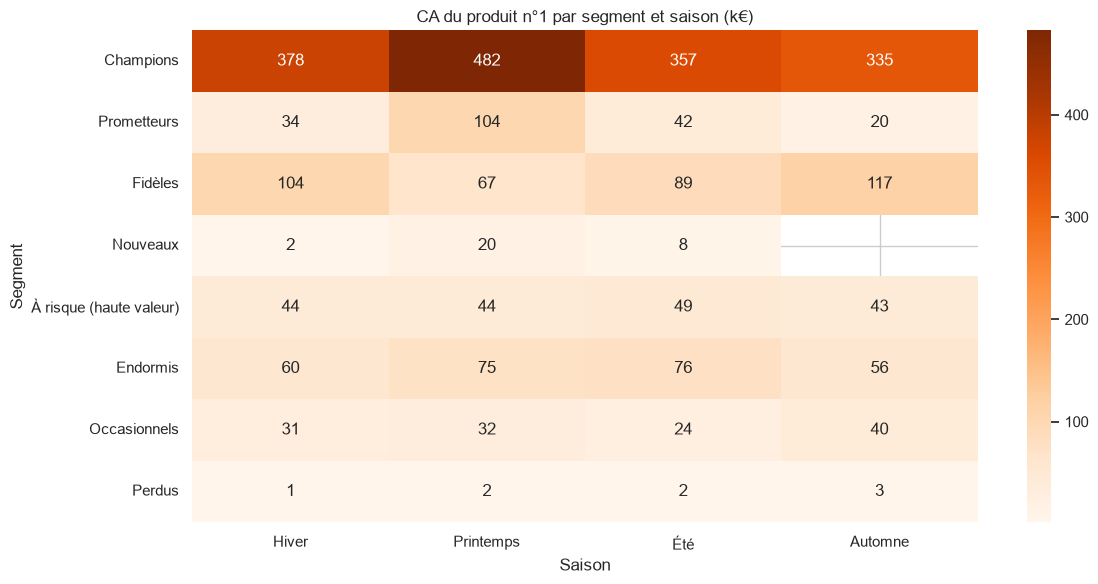


--> Lecture :
    En CA, le n°1 n'est plus le contour yeux / savon / trousse : ce sont les coffrets (ticket plus élevé).
    Champions : Coffret Découverte Rituel Slow Beauty aux 4 saisons.
    Prometteurs, À risque, Endormis : Coffret Duo Visage Bio aux 4 saisons.
    Fidèles : Duo Visage en hiver/printemps, Slow Beauty en été/automne.
    Occasionnels : coffret en hiver/automne, Contour des Yeux au printemps/été.
    Perdus : petits tickets, pas de coffret (beurre corps, contour yeux, huile ricin, huile de bain).


In [11]:
print("\n\n------------------------------------------------ PRODUIT N°1 EN CA : SEGMENT × SAISON ----------------------------------------------")
print("Même croisement, mais le gagnant est celui qui génère le plus de line_total (€), pas le plus d'unités.")

top_ca_seg_saison = ventes.loc[ventes.groupby(["segment", "saison"], observed=True)["ca"].idxmax()].copy()
top_ca_seg_saison["segment"] = pd.Categorical(top_ca_seg_saison["segment"], categories=ordre_segments, ordered=True)
top_ca_seg_saison["saison"] = pd.Categorical(top_ca_seg_saison["saison"], categories=ordre_saisons, ordered=True)
top_ca_seg_saison = top_ca_seg_saison.sort_values(["segment", "saison"])

print("\n====== DÉTAIL ======")
print(top_ca_seg_saison[["segment", "saison", "product_name", "category", "unites", "ca"]].round({"ca": 0}).to_string(index=False))

matrice_produit_ca = (
    top_ca_seg_saison.pivot(index="segment", columns="saison", values="product_name")
    .reindex(index=ordre_segments, columns=ordre_saisons)
    .fillna("—")
)
matrice_categorie_ca = (
    top_ca_seg_saison.pivot(index="segment", columns="saison", values="category")
    .reindex(index=ordre_segments, columns=ordre_saisons)
    .fillna("—")
)
matrice_ca = (
    top_ca_seg_saison.pivot(index="segment", columns="saison", values="ca")
    .reindex(index=ordre_segments, columns=ordre_saisons)
)

print("\n====== MATRICE PRODUIT (n°1 en CA) ======")
print(matrice_produit_ca.to_string())
print("\n====== MATRICE CATÉGORIE ======")
print(matrice_categorie_ca.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(matrice_ca / 1000, annot=True, fmt=".0f", cmap="Oranges", ax=ax)
ax.set_title("CA du produit n°1 par segment et saison (k€)")
ax.set_xlabel("Saison")
ax.set_ylabel("Segment")
plt.tight_layout()
plt.show()

print("\n--> Lecture :")
print("    En CA, le n°1 n'est plus le contour yeux / savon / trousse : ce sont les coffrets (ticket plus élevé).")
print("    Champions : Coffret Découverte Rituel Slow Beauty aux 4 saisons.")
print("    Prometteurs, À risque, Endormis : Coffret Duo Visage Bio aux 4 saisons.")
print("    Fidèles : Duo Visage en hiver/printemps, Slow Beauty en été/automne.")
print("    Occasionnels : coffret en hiver/automne, Contour des Yeux au printemps/été.")
print("    Perdus : petits tickets, pas de coffret (beurre corps, contour yeux, huile ricin, huile de bain).")

## Campagnes marketing (fidélisation, upgrade, cross-sell)

En CA, le n°1 n'est plus le contour yeux / savon / trousse : ce sont les **coffrets** (ticket plus élevé). La fidélisation et l'upgrade passent par le coffret ; le volume (contour, savon, trousse, huile ricin) sert de **porte d'entrée** et de **réassort**.

### Logique de campagne

| Objectif | Mécanique | SKU à pousser |
|---|---|---|
| Fidéliser | réassort + rituel | le coffret déjà acheté par le segment |
| Upgrader le segment | 2e commande / coffret supérieur | Duo Visage → Slow Beauty |
| Cross-sell | ajouter une famille autour du n°1 volume | Visage ↔ Corps ↔ Cheveux ↔ Accessoire |

---

### 1. Champions — fidéliser (pas d'upgrade)

Ils achètent déjà le **Coffret Découverte Rituel Slow Beauty** aux 4 saisons. Risque : les spammer et les faire partir.

- **Offre** : réassort anticipé du Slow Beauty + 1 produit unitaire offert selon la saison (contour yeux en hiver, savon au printemps, trousse en été, huile ricin en automne).
- **Canal** : email VIP + SMS rare, avant-première, pas de -30 %.
- **Succès** : ≥ 1 commande / 60 jours ; panier coffret stable.

### 2. Prometteurs → Champions — upgrade coffret

Ils sont calés sur le **Coffret Duo Visage Bio** toute l'année. Les Champions sont sur le **Slow Beauty**.

- **Offre** : « Passez du Duo au rituel complet » — Slow Beauty à tarif découverte **une fois**, si 2e commande sous 45 jours.
- **Cross-sell** : autour du Duo, ajouter le contour yeux (leur n°1 volume en été) ou la trousse (printemps).
- **Succès** : % qui achètent un Slow Beauty dans les 90 jours.

### 3. Fidèles → Champions — rider la saison

Ils font déjà Duo Visage en **hiver/printemps** et Slow Beauty en **été/automne**. L'upgrade, c'est d'ancrer le Slow Beauty **aussi** en hiver/printemps.

- **Offre** : janvier et avril, bundle Duo + Slow Beauty (ou geste Slow Beauty si réassort Duo).
- **Cross-sell** : contour yeux (leur n°1 volume 3 saisons) dans le même email que le coffret.
- **Succès** : part de Slow Beauty dans leur CA hiver/printemps.

### 4. À risque — winback (avant Perdus)

Même driver CA que les Prometteurs : **Coffret Duo Visage Bio** aux 4 saisons. Dernier achat ≥ 310 jours.

- **Offre unique** : Duo Visage + réassort contour yeux (leur n°1 volume hiver–été), valable 14 jours.
- **Pas** de Slow Beauty d'abord : trop cher pour un compte froid.
- **Succès** : réactivation à 30 jours. Si non → 1 relance puis stop spend.

### 5. Endormis — winback coffret, 1 coup

CA n°1 = **Coffret Duo Visage Bio** toute l'année. Moins urgents que les À risque.

- **Offre** : 1 email « on vous a manqué » avec Duo Visage, calé sur la saison (coffret cadeau en automne/hiver).
- **Cross-sell light** : trousse (printemps) ou huile ricin (automne), leurs n°1 volume.
- **Succès** : réactivation 30 jours ; pas de séquence longue.

### 6. Nouveaux → Prometteurs — 2e commande

Peu de volume, mais le CA n°1 est déjà un **coffret**. Fenêtre courte (1 facture, ≤ 138 j). Pas d'automne.

- **Séquence** J+3 usage / J+15 rituel / J+40 2e commande.
- **Offre 2e commande** : le coffret opposé (s'ils ont le Slow Beauty → Duo, et inversement) **ou** le SKU volume de la saison (savon au printemps, eau micellaire en été).
- **Succès** : taux de 2e commande à 45 jours.

### 7. Occasionnels — upgrade par le coffret saisonnier

Ils achètent déjà un coffret en **hiver/automne** ; au **printemps/été** ils restent sur le contour yeux.

- **Campagne calendaire** :
  - sep–fév : pousser Duo Visage / Slow Beauty (ils le paient déjà).
  - mar–août : contour yeux **+** sample coffret (cross-sell, pas remise sèche).
- **Canal** : 100 % auto (newsletter). Pas de pub chère.
- **Succès** : % d'Occasionnels qui achètent un coffret hors hiver/automne.

### 8. Perdus — exclusion, pas de campagne coffret

Pas de coffret, tickets 1,5–2,7 k€ (beurre corps, contour yeux, huile ricin, huile de bain).

- **Action** : hors listes payantes. Au plus 1 email générique, puis arrêt.
- **Pas** de Slow Beauty / Duo : le ROI est nul.

---

### Calendrier (cross-sell saisonnier)

| Saison | Message volume (porte d'entrée) | Message CA (upgrade) |
|---|---|---|
| Hiver | contour yeux | coffret cadeau / Duo ou Slow Beauty |
| Printemps | savon lavande + trousse | Duo Visage (Prometteurs, Fidèles) |
| Été | trousse voyage + contour yeux | Slow Beauty (Fidèles → Champions) |
| Automne | huile ricin | Slow Beauty + Duo (pic coffret) |

### Budget (ordre réel)

1. À risque (Duo + contour, offre courte)
2. Champions (care Slow Beauty, pas de discount)
3. Prometteurs (upgrade Duo → Slow Beauty)
4. Nouveaux (drip 2e commande)
5. Fidèles (Slow Beauty hors saison)
6. Endormis (1 shot Duo)
7. Occasionnels (auto, coffret sep–fév)
8. Perdus (0 €)

Si À risque et Occasionnels reçoivent le même email coffret, la priorisation est théorique : le Duo est réservé aux comptes à forte valeur historique.